In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("diet_recommendation_dataset_1000.csv")

In [3]:
df

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet
0,56,0,145,118,56.1,0,131,169,2,Low Carb
1,46,1,166,62,22.5,0,118,253,2,Diabetic
2,32,0,170,83,28.7,1,78,256,2,Diabetic
3,60,1,162,116,44.2,2,161,199,0,Diabetic
4,25,0,158,61,24.4,1,100,237,1,Heart Healthy
...,...,...,...,...,...,...,...,...,...,...
995,23,1,173,52,17.4,2,172,261,2,Diabetic
996,43,1,165,52,19.1,2,175,156,2,Diabetic
997,21,0,159,70,27.7,1,126,177,0,Low Carb
998,36,1,171,41,14.0,2,149,249,0,Diabetic


In [4]:
df.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal', 'Diet'],
      dtype='object')

In [5]:
df["Gender"].unique()

array([0, 1])

In [9]:
male_height=df[df["Gender"]==0]["Height_cm"]

In [10]:
female_height=df[df["Gender"]==1]["Height_cm"]

In [17]:
#we need check there is difference in the height of male and female 
def permutation_text(sample1,sample2,no_of_samples):
    sample1=np.array(sample1)
    sample2=np.array(sample2)
    D=abs(np.mean(sample1)-np.mean(sample2))
    combined_sample=np.concatenate((sample1,sample2))
    group1=len(sample1)
    total_values=len(combined_sample)
    diff_lst=[]
    for i in range(no_of_samples):
        jumbled_sample=np.random.permutation(combined_sample)
        new_sample1=jumbled_sample[:group1]
        new_sample2=jumbled_sample[group1:total_values]
        diff=abs(np.mean(new_sample1)-np.mean(new_sample2))
        diff_lst.append(diff)
    diff_array=np.array(diff_lst)
    diff_array_sorted=np.sort(diff_array)
    count=0
    for i in diff_array_sorted:
        if i>D:
            count+=1
    percentage=(count/len(combined_sample))*100
    return percentage
    
    

In [18]:
permutation_text(male_height,female_height,1000)

28.9

In [19]:
np.mean(male_height)

np.float64(167.5801526717557)

In [20]:
np.mean(female_height)

np.float64(166.6533613445378)

In [21]:
df

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet
0,56,0,145,118,56.1,0,131,169,2,Low Carb
1,46,1,166,62,22.5,0,118,253,2,Diabetic
2,32,0,170,83,28.7,1,78,256,2,Diabetic
3,60,1,162,116,44.2,2,161,199,0,Diabetic
4,25,0,158,61,24.4,1,100,237,1,Heart Healthy
...,...,...,...,...,...,...,...,...,...,...
995,23,1,173,52,17.4,2,172,261,2,Diabetic
996,43,1,165,52,19.1,2,175,156,2,Diabetic
997,21,0,159,70,27.7,1,126,177,0,Low Carb
998,36,1,171,41,14.0,2,149,249,0,Diabetic


In [22]:
df["Sugar_Level"].unique()

array([131, 118,  78, 161, 100, 167, 130, 148, 117,  94, 105,  77, 142,
       127, 170, 114, 108, 165, 150, 168, 152, 133, 113,  98, 128, 140,
        75,  86,  85, 156, 164,  72,  90, 159, 175, 155, 111, 145,  82,
        80, 123, 173, 126, 109, 178,  71, 163,  79, 149, 119,  81,  92,
        87, 107, 180, 136,  70,  97, 179,  96, 169,  76,  91, 143, 172,
       122,  73, 139, 157, 153, 102, 106, 132, 104,  74, 129, 115, 158,
       125, 146, 171, 144, 166,  89, 112, 160,  84,  99, 147,  93, 101,
       124, 176, 138, 154, 137,  88, 135, 120,  83, 151, 110, 174, 134,
       116, 162,  95, 141, 177, 103, 121])

In [23]:
np.mean(df["Sugar_Level"])

np.float64(125.762)

In [24]:
np.std(df["Sugar_Level"])

31.822089120609288

In [25]:
#the avearge sungar level of a male is 125.762 but after taking a sample of 60 people is showing 130 population
#sd=30--->Ztest 

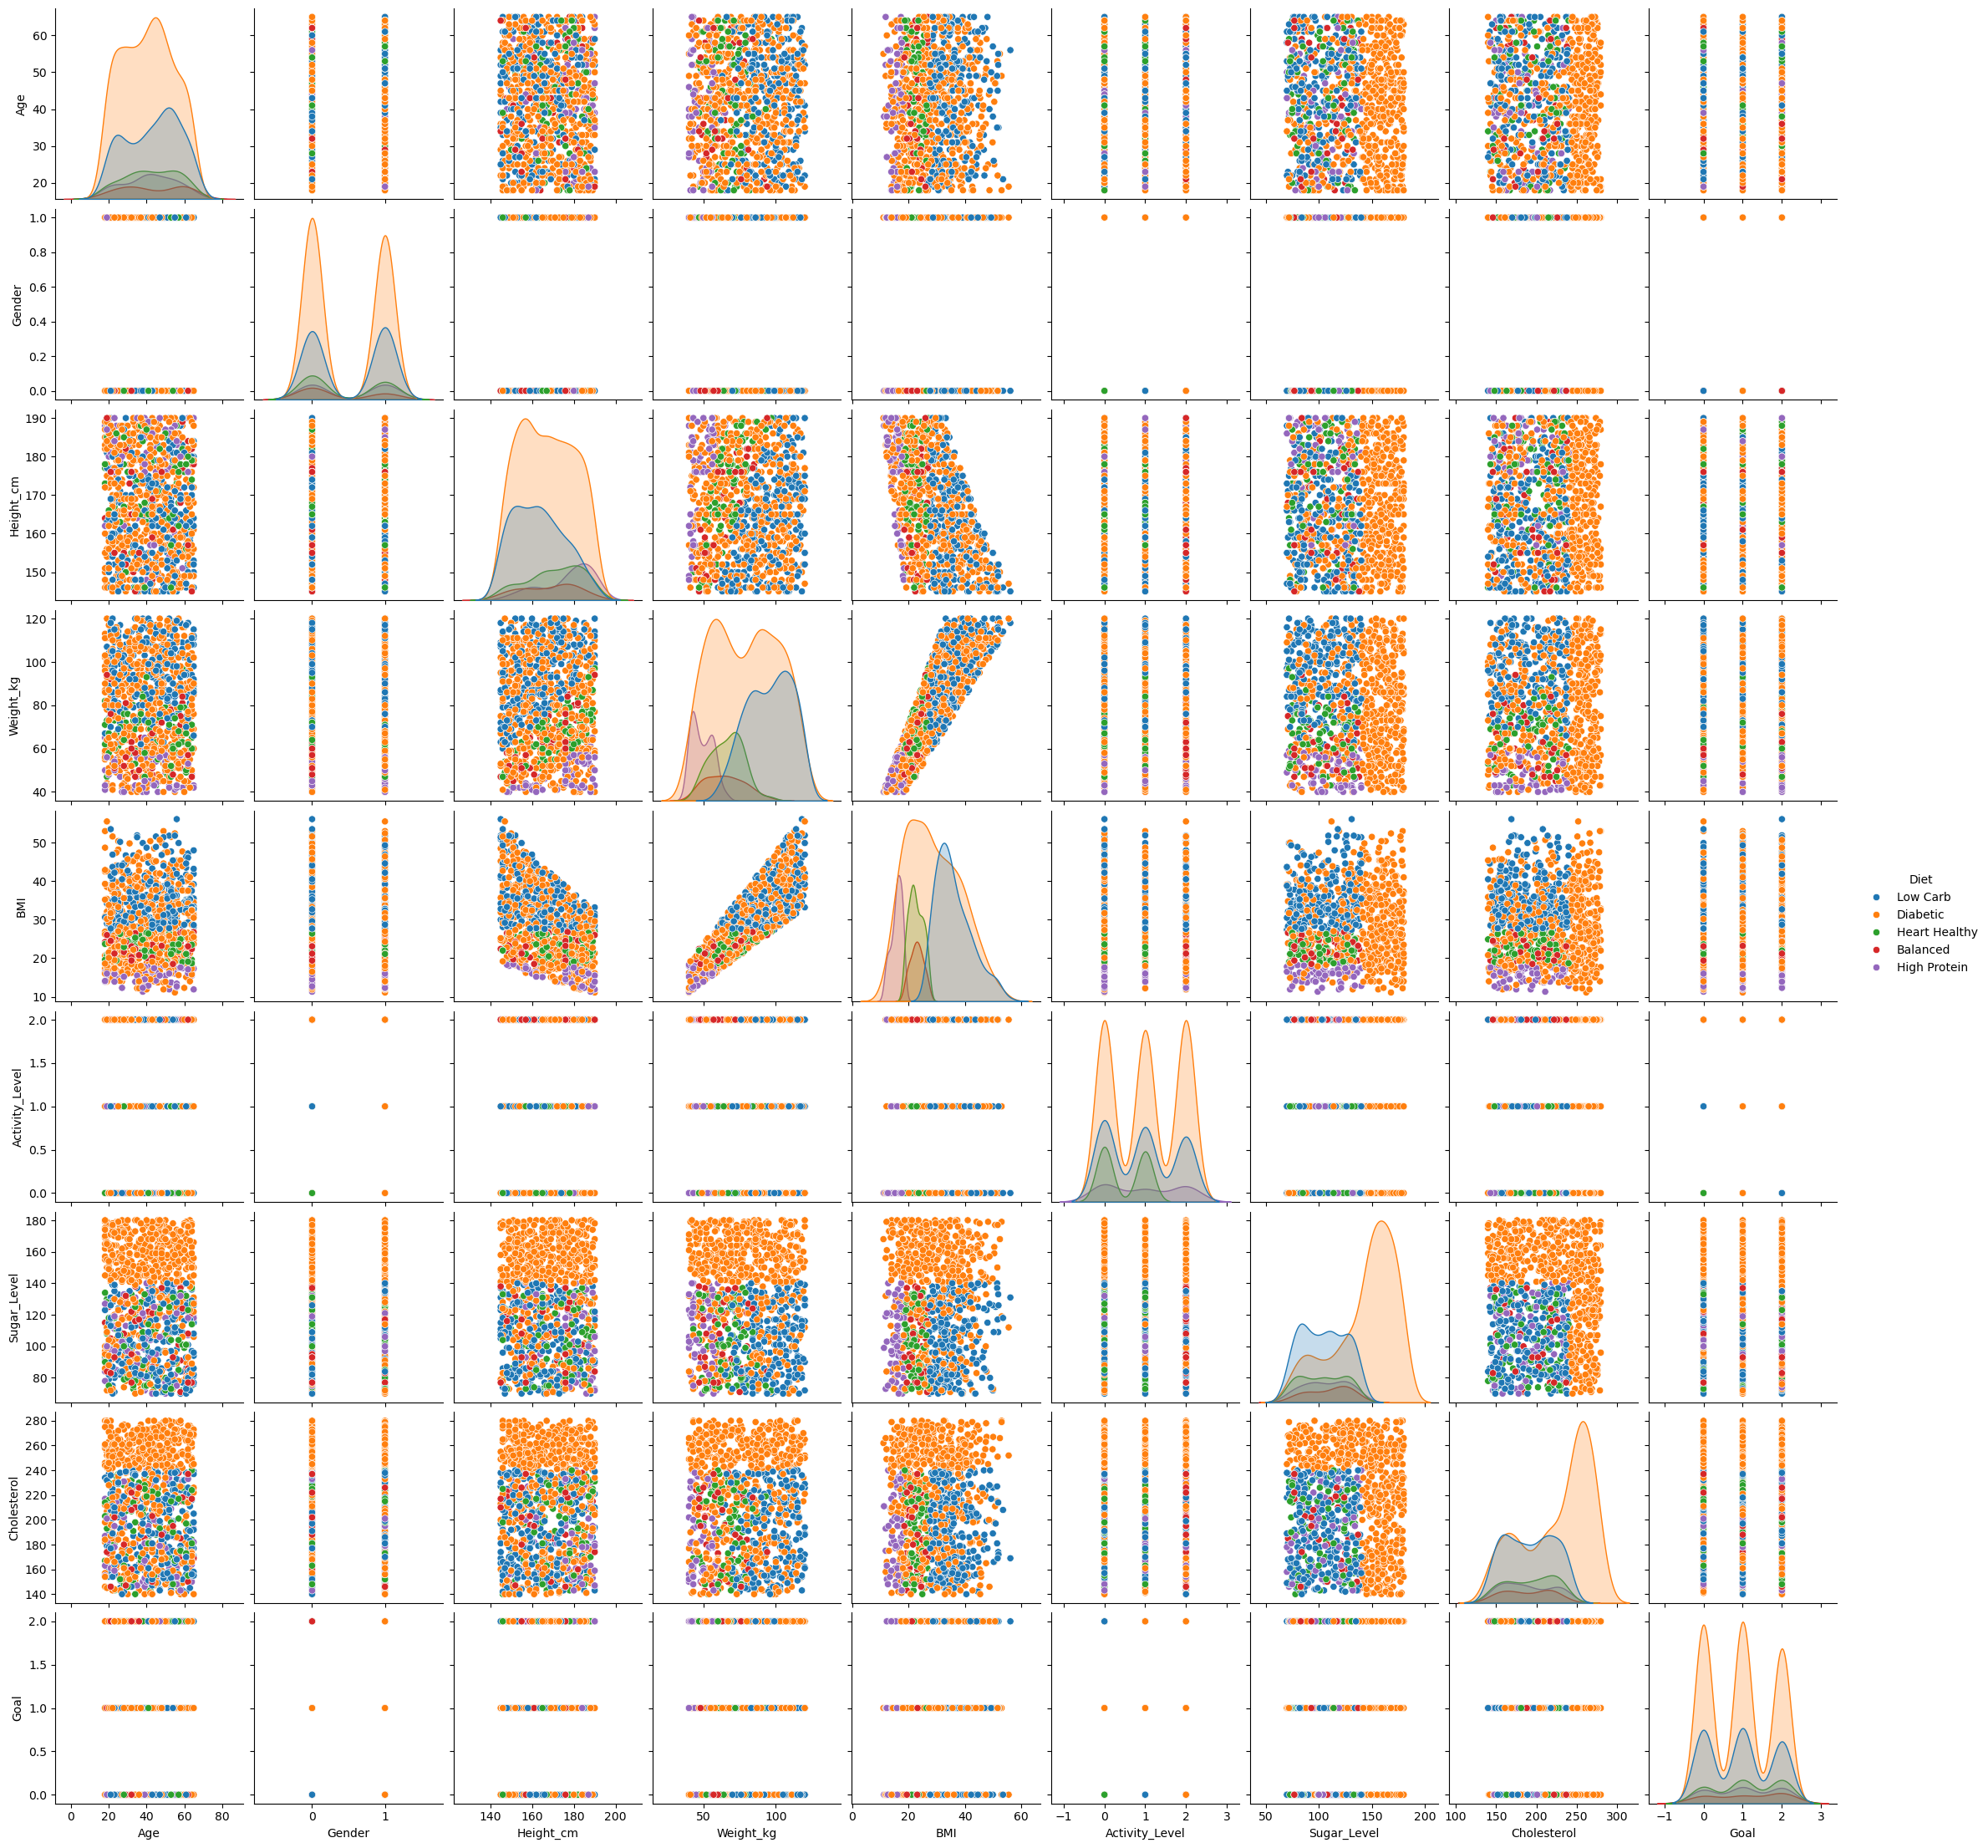

In [26]:
sns.pairplot(df,hue="Diet")